In [1]:
from pathlib import Path
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

In [2]:
def load_peak_stats_for_cell(stats_path, cell_name, usecols=None, chunksize=50000):
    """
    Load only rows for one cell from a large peak-stats CSV.

    Parameters
    ----------
    stats_path : str or Path
    cell_name : str
        Example: "cell_3"
    usecols : list or None
        Columns to load. If None, loads all columns.
    chunksize : int
        Number of rows per chunk.

    Returns
    -------
    pd.DataFrame
    """
    stats_path = Path(stats_path)

    if usecols is not None and "cell" not in usecols:
        usecols = ["cell"] + list(usecols)

    chunks = []
    for chunk in pd.read_csv(stats_path, usecols=usecols, chunksize=chunksize, low_memory=False):
        sub = chunk.loc[chunk["cell"] == cell_name]
        if not sub.empty:
            chunks.append(sub)

    if not chunks:
        return pd.DataFrame(columns=usecols if usecols is not None else None)

    return pd.concat(chunks, ignore_index=True)

def list_cells_in_peak_stats(stats_path, chunksize=50000):
    seen = set()
    for chunk in pd.read_csv(stats_path, usecols=["cell"], chunksize=chunksize):
        seen.update(chunk["cell"].dropna().unique())

    def natural_cell_key(name):
        m = re.match(r"cell_(\d+)$", str(name))
        if m:
            return (0, int(m.group(1)))
        return (1, str(name))

    return sorted(seen, key=natural_cell_key)




In [3]:
# for loading ActSort labels 
def cell_name_to_matlab_idx(cell_name):
    m = re.fullmatch(r"cell_(\d+)", str(cell_name))
    if m is None:
        raise ValueError(f"Could not parse cell name: {cell_name}")
    return int(m.group(1))  # MATLAB-style cell number, e.g. cell_1 -> 1

def is_good_cell(cell_name, labels_overall):
    matlab_idx = cell_name_to_matlab_idx(cell_name)
    python_idx = matlab_idx - 1  # convert MATLAB 1-indexing to Python 0-indexing
    if python_idx < 0 or python_idx >= len(labels_overall):
        return False
    return labels_overall[python_idx] == 1

In [4]:
##path to dataframe 
stats_path = Path("/scratch/jma819/CaliAli_linearTrackData/m328_analysis/all_peak_stats_20260518_152949.csv")

#matching full Ca2+ traces for full length of traces 
csv_path = Path("/scratch/jma819/CaliAli_linearTrackData/m328_analysis/GCAMP_with_velocity.csv")
with csv_path.open("r") as f:
    n_rows = sum(1 for _ in f) - 1  # subtract header


In [5]:
#preview only a few rows 
preview_df = pd.read_csv(stats_path, nrows=10)
preview_df

,cell,event_id,peak_idx,onset_idx,offset_idx,amp_max,length_samples,clip_start,clip_end,clipped_region,X_coor_clipped_region,Y_coor_clipped_region,Velocity_spatial_filtered_clipped_region
0,cell_0,0,5516,4951,27024,11.719598,22073,4941,27034,"[0.39200613, -0.4662587, 0.3849157, 2.0914505,...","[638.8227048675293, 638.3385655112273, 639.447...","[22.31146025878004, 22.63469224620304, 23.2126...","[3.512077960694949, 3.7902020783521553, 3.7902..."
1,cell_0,1,5659,5653,7420,4.337818,1767,5643,7430,"[-0.89008737, 0.13255917, -0.94510293, 0.34430...","[21.340082995850207, 21.306800264482987, 21.30...","[15.476826158692065, 15.43507451299527, 15.435...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,cell_0,2,5991,5925,10084,4.344729,4159,5915,10094,"[1.208883, 0.31606776, 2.4382021, 0.187304, 1....","[21.315164638243857, 22.109111361079865, 23.01...","[17.435376689315316, 17.592575928008998, 17.21...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.6095921527312..."
3,cell_0,3,15676,15520,22122,4.724287,6602,15510,22132,"[0.4562459, 1.2996593, 0.8964366, -0.9973946, ...","[289.86853811510514, 295.1627565576268, 301.44...","[22.61920813416959, 23.38683765892031, 23.8688...","[25.974307792049423, 25.129838082171197, 24.96..."
4,cell_0,4,20568,20442,236912,17.229288,216470,20432,236912,"[1.0173396, -0.8100871, 0.97515935, -0.2899514...","[639.3703386809269, 639.4426242481798, 639.593...","[22.349732620320857, 22.18589743589743, 22.479...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.1142099577776..."
5,cell_0,5,24018,23859,27024,11.719598,3165,23849,27034,"[1.1310248, 0.48373845, 0.70646375, 0.36197016...","[23.884772319242696, 23.007206162511388, 22.68...","[18.59433654316958, 18.44694773461443, 18.5845...","[2.251162242164072, 2.4110414179158406, 2.6091..."
6,cell_0,6,24953,24919,26100,5.809331,1181,24909,26110,"[-0.25366336, 0.4157179, -1.3166586, 0.4649798...","[642.1050029330428, 641.8363102942445, 639.056...","[22.268080113969663, 21.978600396928123, 21.35...","[2.013534343053009, 2.013534343053009, 2.01353..."
7,cell_0,7,27562,27169,49583,17.229288,22414,27159,49593,"[-0.75033855, 2.0543916, -0.07365511, 1.20747,...","[21.2651287723179, 21.2651287723179, 21.595947...","[15.66513930584084, 15.66513930584084, 15.5069...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
8,cell_0,8,29348,29208,29435,3.984060,227,29198,29445,"[1.8314031, -0.46983713, 0.14095113, -1.115783...","[642.2617052023121, 639.8061298512877, 641.567...","[17.652745664739886, 17.80721799056946, 18.876...","[3.5775318509937324, 3.705290561972881, 0.0, 3..."
9,cell_0,9,29817,29763,30442,3.379444,679,29753,30452,"[-0.76034474, 1.3064159, 0.812687, 0.11922715,...","[18.47214595155287, 18.255404791274422, 17.931...","[15.171639514308378, 15.25806661040057, 15.144...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [6]:
#list cells in recording
cells = list_cells_in_peak_stats(stats_path)
cells[:20]

['cell_0',
 'cell_1',
 'cell_2',
 'cell_3',
 'cell_5',
 'cell_6',
 'cell_8',
 'cell_9',
 'cell_10',
 'cell_11',
 'cell_12',
 'cell_13',
 'cell_14',
 'cell_15',
 'cell_16',
 'cell_17',
 'cell_18',
 'cell_19',
 'cell_20',
 'cell_21']

In [ ]:
# load one cell 
cell_stats_df = load_peak_stats_for_cell(stats_path, cell_name="cell_29")


In [22]:
cell_stats_df

,cell,event_id,peak_idx,onset_idx,offset_idx,amp_max,length_samples,clip_start,clip_end
0,cell_29,0,88,39,195,5.087618,156,29,205
1,cell_29,1,573,194,1823,5.599465,1629,184,1833
2,cell_29,2,762,681,1823,5.599465,1142,671,1833
3,cell_29,3,998,958,1217,4.717004,259,948,1227
4,cell_29,4,1109,958,1217,4.717004,259,948,1227
...,...,...,...,...,...,...,...,...,...
605,cell_29,605,224850,224597,226207,7.677852,1610,224587,226207
606,cell_29,606,224908,224597,226207,7.677852,1610,224587,226207
607,cell_29,607,225375,224597,226207,7.677852,1610,224587,226207
608,cell_29,608,225495,224597,226207,7.677852,1610,224587,226207


In [23]:
cell_stats_df.onset_idx

0          39
1         194
2         681
3         958
4         958
        ...  
605    224597
606    224597
607    224597
608    224597
609    224597
Name: onset_idx, Length: 610, dtype: int64

In [24]:
n_rows

226208

In [25]:
# calculate "eventsPerSecond" as whether a "onset_idx" is within a moving 1 second window 
window_len = 20
onset_counts = np.bincount(cell_stats_df["onset_idx"].to_numpy(), minlength=n_rows)
eventsPerSecond_convolve = np.convolve(onset_counts, np.ones(window_len, dtype=int), mode="valid")


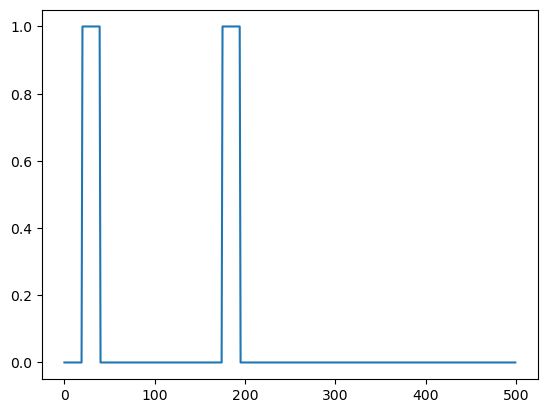

In [26]:
plt.plot(eventsPerSecond_convolve[0:500])

In [31]:
# refilter cells using ActSort labels 
labels_path = Path("/scratch/jma819/CaliAli_linearTrackData/m989_analysis/precomputed_output_LABELS.mat")
mat = sio.loadmat(labels_path, squeeze_me=True, struct_as_record=False)
labels = mat["labels"]
labels_ex = np.asarray(labels.labels_ex).squeeze().astype(int)
labels_ml = np.asarray(labels.labels_ml).squeeze().astype(int)
labels_overall = np.asarray(labels.labels_overall).squeeze().astype(int)
# get good cells 
cells = list_cells_in_peak_stats(stats_path)
good_cells = [cell for cell in cells if is_good_cell(cell, labels_overall)]
len(good_cells)

488

In [ ]:
# calculate "eventsPerSecond" as whether a "onset_idx" is within a moving 1 second window for all cells 
cells = list_cells_in_peak_stats(stats_path)
events_per_second_dict = {}
for cell in cells:
    print(cell)
    cell_stats_df = load_peak_stats_for_cell(stats_path, cell_name=cell)
    # calculate "eventsPerSecond" as whether a "onset_idx" is within a moving 1 second window 
    window_len = 20
    onset_counts = np.bincount(cell_stats_df["onset_idx"].to_numpy(), minlength=n_rows)
    eventsPerSecond_convolve = np.convolve(onset_counts, np.ones(window_len, dtype=int), mode="valid")
    events_per_second_dict[cell] = eventsPerSecond_convolve

cell_0
cell_1
cell_4
cell_5
cell_6
cell_7
cell_8
cell_10
cell_11
cell_12
cell_13
cell_14
cell_15
cell_16
cell_18
cell_19
cell_20
cell_21
cell_22
cell_23
cell_24
cell_25
cell_26
cell_27
cell_28
cell_29
cell_30
cell_31
cell_32
cell_33
cell_34
cell_36


In [13]:
eventsPerSecond_df = pd.DataFrame(events_per_second_dict)

In [14]:
eventsPerSecond_df.mean(axis=0)

cell_0      0.017684
cell_1      0.000088
cell_4      0.015651
cell_5      0.018308
cell_6      0.018038
              ...   
cell_656    0.033954
cell_657    0.044122
cell_658    0.024404
cell_660    0.024152
cell_661    0.030152
Length: 587, dtype: float64

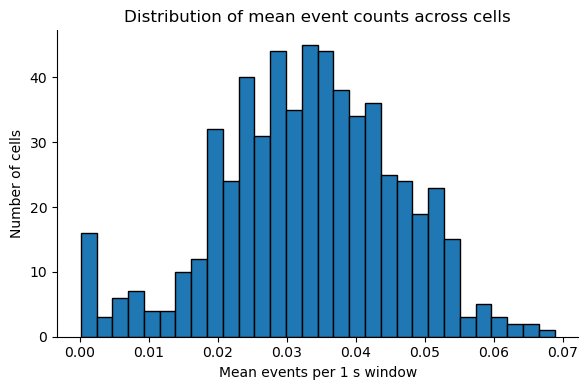

In [15]:
# histogram of firing rate across all cells
import matplotlib.pyplot as plt

mean_events_per_cell = eventsPerSecond_df.mean(axis=0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(mean_events_per_cell, bins=30, edgecolor="black")
ax.set_xlabel("Mean events per 1 s window")
ax.set_ylabel("Number of cells")
ax.set_title("Distribution of mean event counts across cells")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()
